<a href="https://colab.research.google.com/github/AJ180608/Multiple_Linear_Regression/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Section 1: Data Preprocessing
Real-world data is messy. Before feeding it to a model, we must clean and format it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df = df.drop(columns=["ocean_proximity"])

In [ ]:
df.shape

(20640, 9)

In [ ]:
df.nunique()

,0
longitude,844
latitude,862
housing_median_age,52
total_rooms,5926
total_bedrooms,1923
population,3888
households,1815
median_income,12928
median_house_value,3842


In [ ]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
# Setting missing values to mean of column

mean_bedrooms = np.floor(np.mean(df["total_bedrooms"]))
print(mean_bedrooms)

df["total_bedrooms"] = df["total_bedrooms"].fillna(mean_bedrooms)

df.loc[290]

537.0


,290
longitude,-122.160
latitude,37.770
housing_median_age,47.000
total_rooms,1256.000
total_bedrooms,537.000
population,570.000
households,218.000
median_income,4.375
median_house_value,161900.000


In [ ]:
# Checking no of NaN values in each column
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [ ]:
x = df[["longitude","latitude","housing_median_age","total_rooms","total_bedrooms","population","households","median_income"]].to_numpy()
y = df['median_house_value'].to_numpy()
rows = y.shape[0]
y = y[:,np.newaxis]
y

array([[452600.],
       [358500.],
       [352100.],
       ...,
       [ 92300.],
       [ 84700.],
       [ 89400.]])

In [ ]:
# Normalising Values of x
x_mean = np.mean(x,axis=0)
x_std = np.std(x,axis=0)

x_norm = (x - x_mean)/x_std
x = x_norm

### Section 2: Mathematical Foundations
Now we set up the architecture of our single-neuron model.

In [ ]:
def initialize_parameters(num_features):
    """
    Initializes the weights as a numpy array of zeros and bias as 0.
    """
    weights = np.zeros((num_features,1))
    bias = 0

    return weights, bias

def predict(x, weights, bias):
    """
    Calculates the forward pass prediction using the linear regression formula.
    """
    pred = np.matmul(x,weights) + bias
    return pred

def cost_func(y, pred):
    """
    Calculates the Mean Squared Error (MSE) between actual y and predicted values.
    """
    # mse = ...
    n = y.shape[0]
    L = y - pred
    mse = (1/n) * np.sum(L**2)
    return mse

### Section 3: The Learning Algorithm
This is where the magic happens. We will update our weights and bias to minimize the cost function.

In [ ]:
def gradient_descent(x, y, weights, bias, learning_rate, iterations):
    """
    Updates weights and bias iteratively to minimize the cost function.
    """

    m = len(y) # Number of training examples

    for i in range(iterations):
        # 1. Calculate predictions
        # pred = ...
        pred = predict(x,weights,bias)
        mse = cost_func(y,pred)

        # 2. Calculate gradients (dw and db)
        # dw = ... (Hint: use dot product of x.T and the error)
        # db = ... (Hint: sum the errors)

        dw = (-2/m)*(x.T @ (y - pred))
        db = (-2/m)*np.sum(y - pred)

        # 3. Update parameters
        # weights = ...
        # bias = ...

        weights = weights - (dw*learning_rate)
        bias = bias - (db*learning_rate)

        # Print cost every 1000 iterations for debugging
        if i % 1000 == 0:
            print(mse)

    return weights, bias

### Section 4: Training and Evaluation
Let's put it all together and see how our model performs.

In [ ]:
# 1. Initialize parameters based on your feature shape
# num_features = ...
# weights, bias = ...

num_features = 8
w,b = initialize_parameters(num_features)

# 2. Train the model
learning_rate = 0.01
iterations = 40000
# weights, bias = ...

w,b = gradient_descent(x,y,w,b,learning_rate,iterations)

# 3. Final Evaluation
# final_pred = ...
# final_cost = ...
final_pred = predict(x,w,b)
final_cost = cost_func(y,final_pred)


# 4. Print MSE for final model
print("Final MSE: ", final_cost)


56104831989.87253
4918297373.806422
4856938027.488049
4852401877.021224
4851815189.415954
4851693981.627916
4851657775.742379
4851643961.506166
4851638025.648612
4851635354.366422
4851634132.561802
4851633570.660058
4851633311.773405
4851633192.423866
4851633137.391473
4851633112.014217
4851633100.311672
4851633094.915086
4851633092.426463
4851633091.278841
4851633090.749616
4851633090.505566
4851633090.393023
4851633090.341123
4851633090.317189
4851633090.306153
4851633090.301064
4851633090.298716
4851633090.297634
4851633090.297135
4851633090.2969055
4851633090.296799
4851633090.29675
4851633090.296727
4851633090.296718
4851633090.296711
4851633090.29671
4851633090.296708
4851633090.296708
4851633090.296707
Final MSE:  4851633090.296707


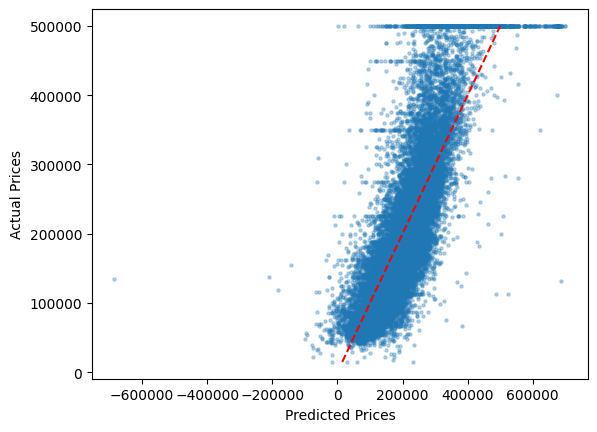

In [ ]:
# Visualization
# 1. Flatten y and final_pred arrays to 1D
# y_flat = ...
# pred_flat = ...

# 2. Sort arrays by actual y values for a smooth line plot

# 3. Plot Actual vs Predicted
y_flat = y.flatten(order="F")
pred_flat = final_pred.flatten(order="F")

indices = np.arange(np.shape(y)[0])

plt.scatter(pred_flat, y_flat,alpha=0.3,s=5,label="Actual Prices")
plt.plot([y_flat.min(), y_flat.max()], [y_flat.min(), y_flat.max()], 'r--')


plt.xlabel("Predicted Prices")
plt.ylabel("Actual Prices")
plt.show()

